In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from PIL import ImageFile

# PCA for Dimensionality Reduction

In [6]:
def PCA_scratch(X, num_components):
    """
    Implements Principal Component Analysis (PCA) for dimensionality reduction.
    Parameters:
        X: ndarray
            The input data matrix with shape (n_samples, n_features).
        num_components: int
            The number of principal components to retain.
    Returns:
        X_reduced: ndarray
            The reduced-dimensional representation of the input data matrix,
            obtained by projecting the data onto the top `num_components` principal components
            It has shape (n_samples, num_components).
    """

    # Standardize the data
    # Compute the mean of the data
    # Move data to center follows standard normal distribution ~ mean = 0, std = 1

    X_meaned = X - np.mean(X, axis=0)

    # Compute the covariance matrix
    # rowvar=False tells NumPy that each column is a feature and each row is an observation. If you have 10 features, 
    # you'll get a 10x10 matrix.
    cov_mat = np.cov(X_meaned, rowvar=False)

    # Perform eigenvalue decomposition
    # eigh is used for symmetric matrices, which is the case for covariance matrices. It returns the eigenvalues and eigenvectors.
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

    # Sort eigenvalues and eigenvectors in descending order
    # argsort returns the indices that would sort the array. [::-1] reverses the order to get descending sort
    sorted_index = np.argsort(eigen_values)[::-1]
    # the largest eigenvalue corresponds to the First Principal Component (the direction where the data is most spread out)
    sorted_eigenvalues = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:, sorted_index]

    # Select the top `num_components` eigenvectors
    # Throwing away noise and less important features, we keep only the top `num_components` eigenvectors that correspond to the largest eigenvalues.
    eigenvector_subset = sorted_eigenvectors[:, :num_components]

    # Project the data onto the selected eigenvectors to obtain the reduced-dimensional representations
    X_reduced = np.dot(eigenvector_subset.transpose(), X_meaned.transpose()).transpose()
    
    return X_reduced

In [7]:
X = np.random.randint(10,50,100).reshape(20,5) 
X

array([[49, 41, 32, 37, 12],
       [46, 34, 39, 48, 30],
       [31, 39, 23, 34, 13],
       [15, 39, 17, 22, 47],
       [44, 14, 13, 17, 32],
       [48, 17, 15, 13, 18],
       [47, 44, 26, 31, 26],
       [40, 28, 28, 31, 12],
       [29, 44, 49, 41, 19],
       [20, 44, 45, 12, 38],
       [38, 43, 12, 25, 27],
       [35, 21, 26, 31, 47],
       [14, 10, 35, 29, 28],
       [20, 49, 45, 12, 27],
       [35, 11, 44, 49, 41],
       [26, 31, 23, 26, 43],
       [47, 33, 44, 11, 31],
       [41, 47, 22, 39, 26],
       [24, 42, 23, 16, 22],
       [18, 14, 19, 27, 22]], dtype=int32)

In [8]:
X_2 = PCA_scratch(X, num_components=2)
X_2

array([[-23.1060507 ,  11.37349269],
       [-14.58750582,  10.60427608],
       [-10.26201636,   3.27872441],
       [ 16.53753132, -17.40158263],
       [ 17.61968258,  16.9964523 ],
       [  8.38327822,  19.036189  ],
       [-14.63390629,   4.8839395 ],
       [ -7.58681934,  12.01725474],
       [-20.09940564,  -8.6867735 ],
       [  1.63241972, -28.6398938 ],
       [ -3.81015335,   2.36006935],
       [ 15.12075674,   4.77496381],
       [ 20.86588101,  -1.34842438],
       [ -6.56471562, -28.60984478],
       [  8.58630548,  12.1920289 ],
       [ 12.68393902,  -5.97757028],
       [ -4.546085  ,  -4.5318861 ],
       [-15.32456072,   4.11274834],
       [ -0.19233994, -11.77835184],
       [ 19.2837647 ,   5.34418818]])

## Eigenfaces

In [9]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [11]:
lfw_people = fetch_lfw_people(data_home="D:\FCDS\Data Computations", min_faces_per_person=70, resize=0.4)

In [12]:
lfw_people

{'data': array([[0.9973857 , 0.99607843, 0.9921568 , ..., 0.38169935, 0.38823533,
         0.3803922 ],
        [0.14771242, 0.19738562, 0.1751634 , ..., 0.45751634, 0.44444445,
         0.53594774],
        [0.34379086, 0.39477125, 0.49150327, ..., 0.709804  , 0.72156864,
         0.7163399 ],
        ...,
        [0.3633987 , 0.3372549 , 0.30718955, ..., 0.19738562, 0.22091503,
         0.19346406],
        [0.19346406, 0.24705882, 0.34248367, ..., 0.7346406 , 0.6640523 ,
         0.6117647 ],
        [0.11633987, 0.10196079, 0.1267974 , ..., 0.13333334, 0.13725491,
         0.2535948 ]], shape=(1288, 1850), dtype=float32),
 'images': array([[[0.9973857 , 0.99607843, 0.9921568 , ..., 0.29803923,
          0.24836601, 0.20653595],
         [0.9973857 , 0.9921569 , 0.9908497 , ..., 0.30588236,
          0.2535948 , 0.21568628],
         [0.96078426, 0.93071896, 0.8679738 , ..., 0.2875817 ,
          0.24183007, 0.21568628],
         ...,
         [0.34509805, 0.26143792, 0.17385621, ..

In [14]:
n_samples, h, w = lfw_people.images.shape
lfw_people.images.shape

(1288, 50, 37)

In [ ]:
X = lfw_people.data
# stores the total number of pixels per image (h * w). In PCA, each pixel is treated as a separate dimension.
n_features = X.shape[1]

In [16]:
n_features

1850

In [18]:
# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

In [19]:
print(f'Number of Data Samples: {n_samples}')
print(f'Size of a data sample: {n_features}')
print(f'Number of Class Labels: {n_classes}')

Number of Data Samples: 1288
Size of a data sample: 1850
Number of Class Labels: 7


In [20]:
# Function to plot images in 3 * 4 
def plot_gallery(images, titles, h, w, n_row = 3, n_col = 4):
    plt.figure(figsize =(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom = 0, left =.01, right =.99, top =.90, hspace =.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap = plt.cm.gray)
        plt.title(titles[i], size = 12)
        plt.xticks(())
        plt.yticks(())

In [21]:
# Generate true labels above the images
def true_title(Y, target_names, i):
    true_name = target_names[Y[i]].rsplit(' ', 1)[-1]
    return f'true label: {true_name}'

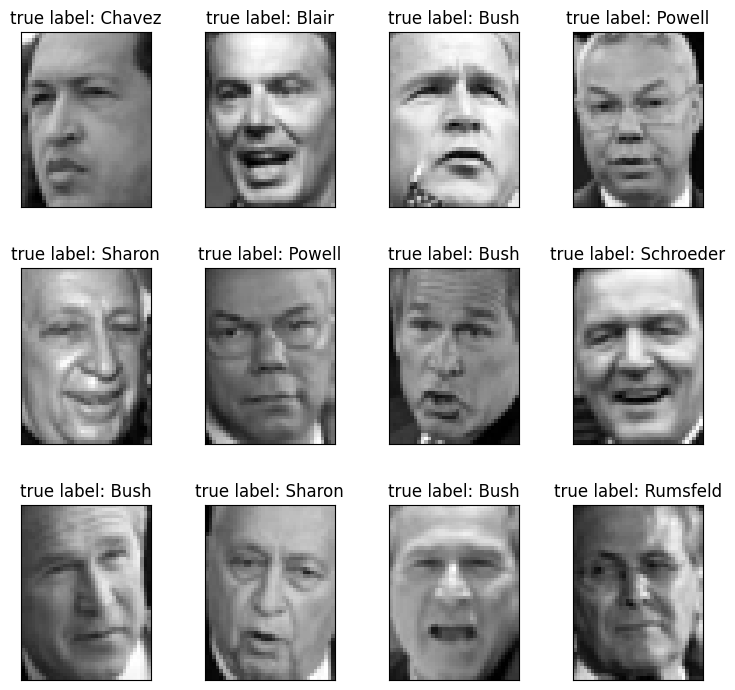

In [25]:
true_titles = [true_title(y, target_names, i) for i in range(y.shape[0])]
plot_gallery(X, true_titles, h, w)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f'size of training data is {y_train.shape[0]} and testing data is {y_test.shape[0]}')

size of training data is 966 and testing data is 322


In [29]:
n_components = 150
pca = PCA(n_components = n_components).fit(X_train)
eigenfaces = pca.components_.reshape((n_components, h, w))
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [30]:
eigenfaces.shape

(150, 50, 37)

In [31]:
X_train.shape

(966, 1850)

In [32]:
X_train_pca.shape

(966, 150)

In [33]:
print("Sample Data point after applying PCA\n", X_train_pca[0])
print("-----------------------------------------------------")
print(f"Dimensions of training set = {X_train_pca.shape} and test set = {X_test_pca.shape}")

Sample Data point after applying PCA
 [ 3.94223404e+00  2.43682528e+00  2.93564343e+00  8.17549944e-01
  1.27328229e+00  4.50374246e-01 -9.02081549e-01 -9.21213210e-01
  4.34589803e-01 -4.17681634e-02 -3.42949629e-02 -4.52075243e-01
  1.71132416e-01 -2.52330303e-03 -1.79910398e+00 -2.32775629e-01
 -9.55171883e-01  1.60493851e+00 -2.27423811e+00 -6.97519720e-01
 -6.36411607e-02  1.20803639e-02 -4.84772444e-01 -1.51968703e-01
 -1.62378639e-01 -5.93190134e-01  1.50946856e-01 -4.39934544e-02
 -1.10665154e+00  4.92486060e-01 -3.48524600e-01 -4.20004763e-02
  2.92704999e-01  7.95698225e-01  4.98830914e-01  4.03194964e-01
 -1.29255176e-01  7.83974171e-01  1.79014400e-01 -6.07213914e-01
  2.25260288e-01 -1.64692178e-01  3.88567895e-01  7.19666705e-02
 -6.20288551e-01  3.69348884e-01  2.46274859e-01  2.71202713e-01
  6.49368823e-01  5.71781158e-01  1.31607842e+00  2.37028599e-02
  4.53096449e-01  6.18566394e-01  3.13567787e-01 -4.73131537e-02
 -4.38096344e-01  3.44674081e-01 -3.62501815e-02 -2.

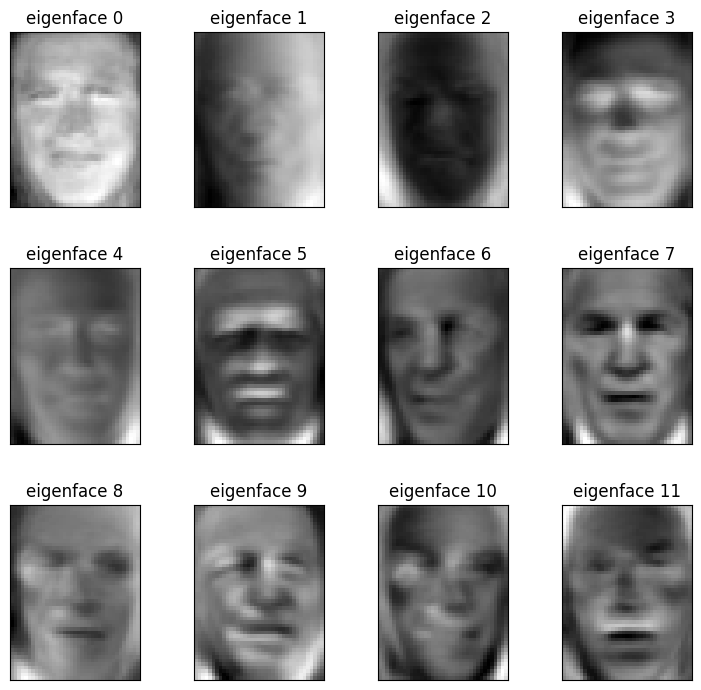

In [34]:
eigenfaces_titles = [f'eigenface {i}' for i in range(n_components)]
plot_gallery(eigenfaces, eigenfaces_titles, h, w)

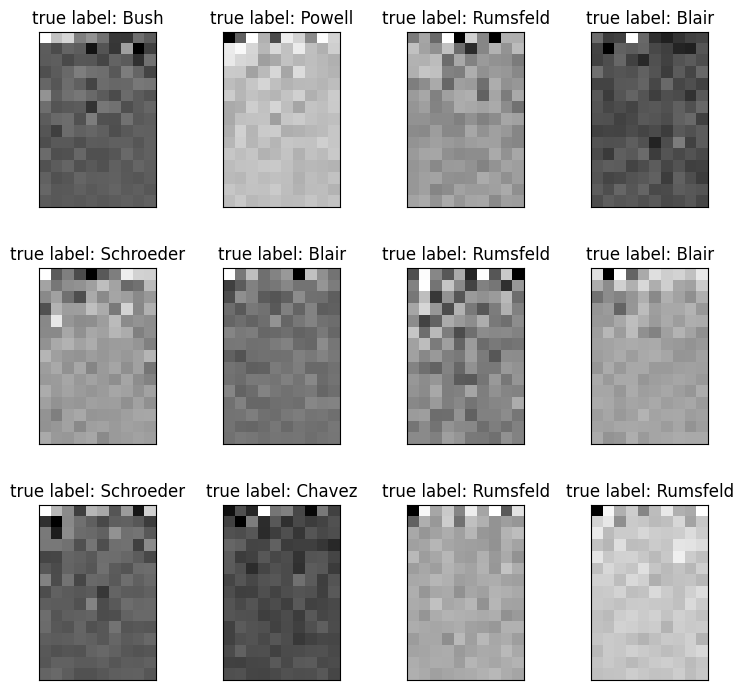

In [35]:
true_titles_train = [true_title(y_train, target_names, i) for i in range(y_train.shape[0])]
plot_gallery(X_train_pca, true_titles_train, 15, 10)

## Face Recognition using Eigenfaces

In [56]:
svc = SVC(random_state=41)
svc.fit(X_train_pca, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [57]:
y_pred = svc.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.38      0.56        13
     Colin Powell       0.78      0.83      0.81        60
  Donald Rumsfeld       0.82      0.52      0.64        27
    George W Bush       0.73      0.97      0.84       146
Gerhard Schroeder       0.79      0.44      0.56        25
      Hugo Chavez       0.83      0.33      0.48        15
       Tony Blair       0.86      0.53      0.66        36

         accuracy                           0.76       322
        macro avg       0.83      0.57      0.65       322
     weighted avg       0.78      0.76      0.74       322



In [58]:
def true_title_pred(Y, pred_names, target_names, i):
    true_name = target_names[Y[i]].rsplit(' ', 1)[-1]
    return f'true: {true_name}\n predicted: {pred_names[i]}'

In [59]:
y_pred_names = [target_names[i].rsplit(' ', 1)[-1] for i in y_pred]

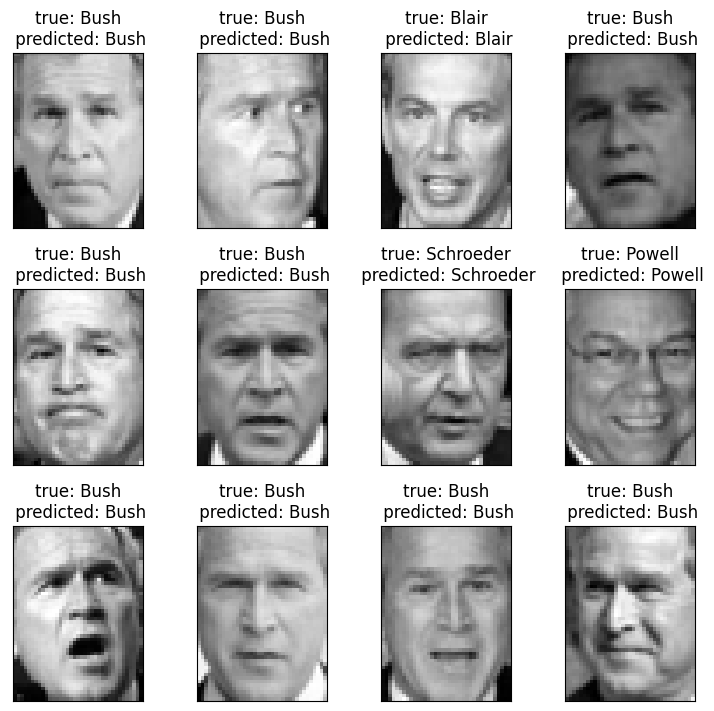

In [60]:
true_titles_test = [true_title_pred(y_test, y_pred_names, target_names, i) for i in range(y_test.shape[0])]
plot_gallery(X_test, true_titles_test, h, w)

Trying less number of components

In [84]:
n_components = 50
pca = PCA(n_components = n_components).fit(X_train)

In [85]:
eigenfaces = pca.components_.reshape((n_components, h, w))
X_train_pca_50 = pca.transform(X_train)
X_test_pca_50 = pca.transform(X_test)

In [86]:
X_train_pca_50.shape

(966, 50)

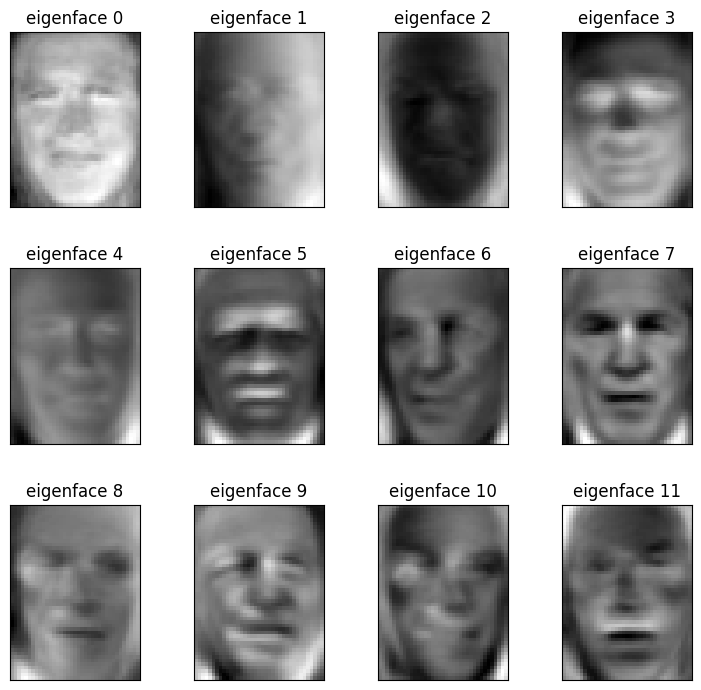

In [87]:
eigenfaces_titles = [f'eigenface {i}' for i in range(n_components)]
plot_gallery(eigenfaces, eigenfaces_titles, h, w)

In [88]:
svc_50 = SVC(random_state=41)
svc_50.fit(X_train_pca_50, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [89]:
y_pred_50 = svc_50.predict(X_test_pca_50)
print(classification_report(y_test, y_pred_50, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.83      0.38      0.53        13
     Colin Powell       0.77      0.80      0.79        60
  Donald Rumsfeld       0.82      0.52      0.64        27
    George W Bush       0.75      0.97      0.84       146
Gerhard Schroeder       0.73      0.44      0.55        25
      Hugo Chavez       0.71      0.33      0.45        15
       Tony Blair       0.73      0.53      0.61        36

         accuracy                           0.75       322
        macro avg       0.77      0.57      0.63       322
     weighted avg       0.76      0.75      0.74       322

